# GameStop Stock Price Prediction

**Group members:**
- odamu0185
- nebro9110

This project uses historical GameStop stock data to predict the closing price for a given date.  
The input is a date, and the output is a predicted closing price in US dollars.

## Choice of algorithm

We chose Linear Regression because the target variable, closing price, is a continuous numerical value.  
The date is converted into the number of days since the first date in the dataset.  
Linear Regression is simple, easy to understand, and can predict a price for a given date.  
Stock prices are complex, so this model should be viewed as a learning example rather than financial advice.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
#importerer bibliotek

df = pd.read_csv("data/GME_stock.csv")

df["date"] = pd.to_datetime(df["date"]) # Datoen blir lest inn som string, så for å kunne jobbe med dataen konverteres den til datetime.

print("Antall rader:", len(df))
print("Kolonner:", df.columns.tolist())

df.head()

Antall rader: 4773
Kolonner: ['date', 'open_price', 'high_price', 'low_price', 'close_price', 'volume', 'adjclose_price']


,date,open_price,high_price,low_price,close_price,volume,adjclose_price
0,2021-01-28,265.000000,483.000000,112.250000,193.600006,58815800.0,193.600006
1,2021-01-27,354.829987,380.000000,249.000000,347.510010,93396700.0,347.510010
2,2021-01-26,88.559998,150.000000,80.199997,147.979996,178588000.0,147.979996
3,2021-01-25,96.730003,159.179993,61.130001,76.790001,177874000.0,76.790001
4,2021-01-22,42.590000,76.760002,42.320000,65.010002,196784300.0,65.010002


## Data preparation

The date column is converted from text to a datetime value.  
Rows with missing dates or closing prices are removed, and the data is sorted chronologically.  
The date is then converted into the number of days since the first date in the dataset.

In [10]:
df = (
    df.dropna(subset=["date", "close_price"])
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

print("Number of rows after cleaning:", len(df))

df[["date", "close_price"]].head()

Number of rows after cleaning: 4773


,date,close_price
0,2002-02-13,10.050
1,2002-02-14,10.000
2,2002-02-15,9.950
3,2002-02-19,9.550
4,2002-02-20,9.875


In [11]:
print("First date:", df["date"].min().date())
print("Last date:", df["date"].max().date())

df["close_price"].describe()

First date: 2002-02-13
Last date: 2021-01-28


count    4773.000000
mean       23.193234
std        14.513893
min         2.800000
25%        11.350000
50%        21.760000
75%        29.430000
max       347.510010
Name: close_price, dtype: float64

## Historical closing prices

The graph below shows how GameStop's closing price has changed over time.

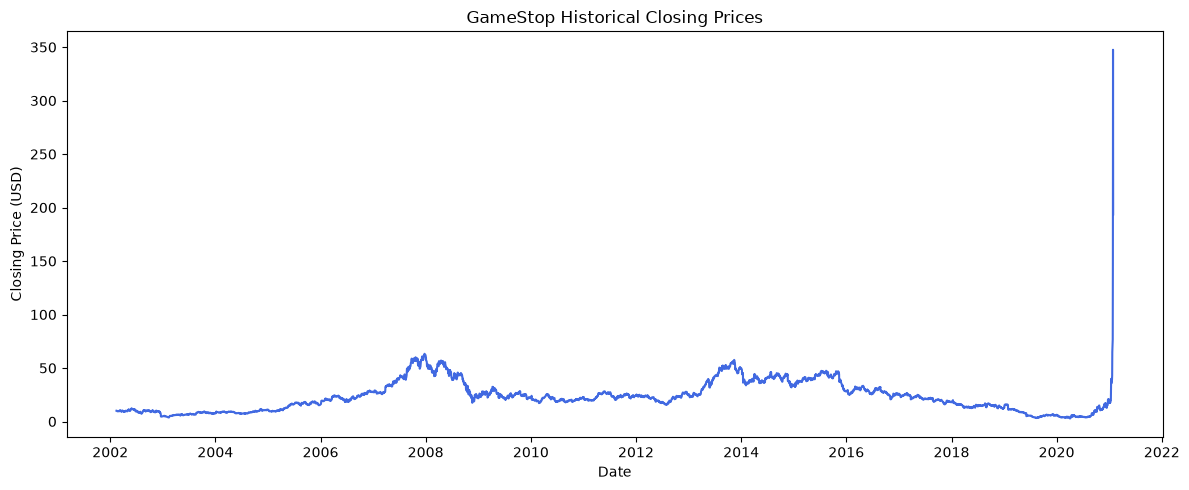

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["close_price"], color="royalblue")

plt.title("GameStop Historical Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.tight_layout()
plt.show()

## Preparing the feature and target

The input feature is the date, and the target is the closing price.  
Because Linear Regression requires numerical input, each date is converted into the number of days since the first date in the dataset.

In [14]:
start_date = df["date"].min()

df["days_since_start"] = (df["date"] - start_date).dt.days

X = df[["days_since_start"]]
y = df["close_price"]

df[["date", "days_since_start", "close_price"]].head()

,date,days_since_start,close_price
0,2002-02-13,0,10.050
1,2002-02-14,1,10.000
2,2002-02-15,2,9.950
3,2002-02-19,6,9.550
4,2002-02-20,7,9.875


## Train-test split

The first 80% of the observations are used to train the model, while the final 20% are used to test it.  
A chronological split is used because future stock prices should not be used to predict earlier stock prices.

In [15]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

train_dates = df["date"].iloc[:split_index]
test_dates = df["date"].iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print()
print("Training period:", train_dates.min().date(), "to", train_dates.max().date())
print("Testing period:", test_dates.min().date(), "to", test_dates.max().date())

Training rows: 3818
Testing rows: 955

Training period: 2002-02-13 to 2017-04-12
Testing period: 2017-04-13 to 2021-01-28


## Model training

A Linear Regression model is trained using the numerical date feature and the historical closing prices.  
The trained model is then used to predict the closing prices in the test period.

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("The model has been trained.")

The model has been trained.


## Model evaluation

The regression model is evaluated using Mean Absolute Error, Root Mean Squared Error, and the R² score.  
MAE and RMSE show the prediction error in dollars, while R² measures how much of the price variation is explained by the model.

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² score: {r2:.4f}")

Mean Absolute Error (MAE): $30.91
Root Mean Squared Error (RMSE): $33.38
R² score: -4.0741


In [18]:
results = pd.DataFrame({
    "date": test_dates.to_numpy(),
    "actual_price": y_test.to_numpy(),
    "predicted_price": y_pred,
})

results.head(10)

,date,actual_price,predicted_price
0,2017-04-13,22.379999,39.213057
1,2017-04-17,22.889999,39.232482
2,2017-04-18,22.840000,39.237338
3,2017-04-19,22.780001,39.242194
4,2017-04-20,23.190001,39.247051
5,2017-04-21,23.190001,39.251907
6,2017-04-24,23.219999,39.266476
7,2017-04-25,23.400000,39.271332
8,2017-04-26,23.650000,39.276188
9,2017-04-27,23.100000,39.281044


## Actual and predicted prices

The graph compares the actual GameStop closing prices with the prices predicted by the Linear Regression model during the test period.

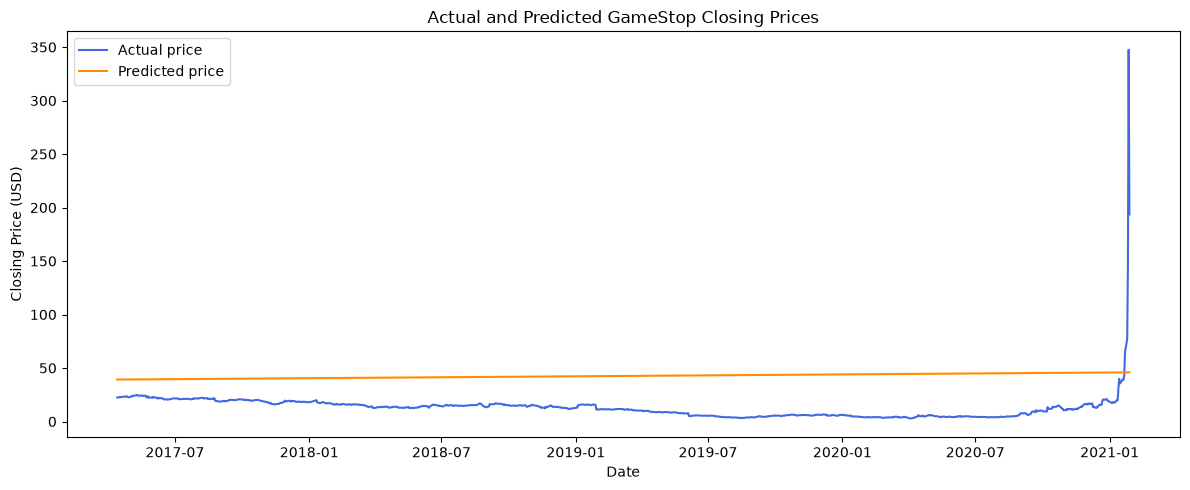

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    results["date"],
    results["actual_price"],
    label="Actual price",
    color="royalblue",
)

plt.plot(
    results["date"],
    results["predicted_price"],
    label="Predicted price",
    color="darkorange",
)

plt.title("Actual and Predicted GameStop Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

## Accuracy score and confusion matrix

Accuracy and confusion matrices are normally used for classification, not regression.  
To include them, the actual and predicted prices are divided into the categories Low and High.  
The median closing price from the training data is used as the boundary between the two categories.  
The Linear Regression model still predicts a numerical closing price.

In [ ]:
price_limit = y_train.median()

actual_categories = np.where(y_test <= price_limit, "Low", "High")
predicted_categories = np.where(y_pred <= price_limit, "Low", "High")

category_accuracy = accuracy_score(
    actual_categories,
    predicted_categories,
)

print(f"Boundary between Low and High: ${price_limit:.2f}") 
print(f"Category accuracy: {category_accuracy:.2%}") #resultatet er da accuracyen for kategoriene 'Low' og 'High', ikke for den nøyaktige dollarprisen.

Boundary between Low and High: $23.98
Category accuracy: 2.20%


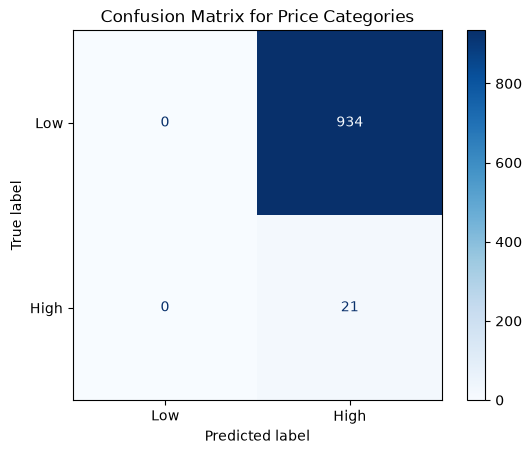

In [ ]:
cm = confusion_matrix(
    actual_categories,
    predicted_categories,
    labels=["Low", "High"],
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "High"],
)

display.plot(cmap="Blues")
plt.title("Confusion Matrix for Price Categories")
plt.show()
#Confusion matrix viser:

#Faktiske lave priser som ble predikert som lave
#Faktiske lave priser som ble predikert som høye
#Faktiske høye priser som ble predikert som lave
#Faktiske høye priser som ble predikert som høye